# T2 · The two jobs: solving an equation, and recovering a constant

[T1](T1_what_is_a_pinn.ipynb) solved a fully known equation, the **forward**
problem, where an ODE integrator beats a PINN easily.

The **inverse** problem is the one worth caring about. The law's *form* is
known; one of its constants is not, and you have a handful of noisy
measurements. Now the network has two jobs at once:

1. satisfy the equation, and
2. pass near the data,

and the unknown constant is trained alongside the weights.

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np, torch, matplotlib.pyplot as plt
from physprior.viz import plots as P
P.use_style()
torch.set_default_dtype(torch.float64)
print("torch", torch.__version__)

torch 2.11.0


## The setup: eight noisy points, and an unknown frequency

The truth is $\omega = 2$ and we pretend not to know it. Eight measurements,
5% noise. A curve fit would recover $\omega$ from these too; the point here
is the *mechanism*, which generalises to equations that have no closed-form
solution to fit.

In [2]:
OMEGA_TRUE = 2.0
rng = np.random.default_rng(0)
t_data = np.sort(rng.uniform(0, 3, 8))
x_data = np.cos(OMEGA_TRUE * t_data) + rng.normal(0, 0.05, 8)
t_d = torch.tensor(t_data); x_d = torch.tensor(x_data)
print("t:", t_data.round(3)); print("x:", x_data.round(3))

t: [0.05  0.123 0.809 1.82  1.911 2.188 2.44  2.738]
x: [ 0.96   0.907 -0.079 -0.876 -0.894 -0.34   0.104  0.655]


## The unknown constant is just another parameter

`omega` is a `torch.nn.Parameter`, optimised by the same Adam step as the
weights. It is trained **in log space**: it is positive by physics, and the
log keeps it positive without a constraint while making the search
scale-free.

In [3]:
def mlp(width=32, depth=3):
    layers = [torch.nn.Linear(1, width), torch.nn.Tanh()]
    for _ in range(depth - 1):
        layers += [torch.nn.Linear(width, width), torch.nn.Tanh()]
    return torch.nn.Sequential(*layers, torch.nn.Linear(width, 1))

torch.manual_seed(0)
net = mlp()
log_omega = torch.nn.Parameter(torch.tensor(0.0))   # omega = exp(0) = 1, wrong on purpose

def omega():
    return torch.exp(log_omega)

def x_of(t):
    return 1.0 + t**2 * net(t.unsqueeze(-1)).squeeze(-1)

print(f"omega starts at {float(omega()):.3f}, truth is {OMEGA_TRUE}")

omega starts at 1.000, truth is 2.0


## Two terms in the loss, and the weight between them

$$\mathcal{L} = \underbrace{\frac{1}{N_d}\sum (x_\theta(t_i) - x_i)^2}_{\text{data}}
 \;+\; w_{\text{phys}} \underbrace{\frac{1}{N_c}\sum \left[\ddot x_\theta + \omega^2 x_\theta\right]^2}_{\text{physics}}$$

`w_phys` is the dial this whole repository is built around. Turn it to zero
and you have an ordinary curve fit that happens to carry an unused symbol
called `omega`; turn it up and the equation dominates.

In [4]:
t_colloc = torch.linspace(0, 3, 200)

def train(w_phys, epochs=4000, seed=0):
    torch.manual_seed(seed)
    global net, log_omega
    net = mlp(); log_omega = torch.nn.Parameter(torch.tensor(0.0))
    opt = torch.optim.Adam(list(net.parameters()) + [log_omega], lr=5e-3)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    track = []
    for epoch in range(epochs):
        opt.zero_grad()
        data = torch.mean((x_of(t_d) - x_d)**2)
        t = t_colloc.clone().requires_grad_(True)
        x = x_of(t)
        dx = torch.autograd.grad(x.sum(), t, create_graph=True)[0]
        d2x = torch.autograd.grad(dx.sum(), t, create_graph=True)[0]
        phys = torch.mean((d2x + omega()**2 * x)**2)
        (data + w_phys * phys).backward(); opt.step(); sched.step()
        if epoch % 50 == 0:
            track.append((epoch, float(omega())))
    return float(omega()), track, float(data)

omega_hat, track, data_loss = train(w_phys=1.0)
print(f"recovered omega = {omega_hat:.4f}   truth {OMEGA_TRUE}   "
      f"error {abs(omega_hat-OMEGA_TRUE)/OMEGA_TRUE*100:.2f}%")

recovered omega = 1.9791   truth 2.0   error 1.04%


## The dial, swept

This is the single most important plot in the subject. Watch the recovered
constant as `w_phys` goes from 0 to large.

In [5]:
rows = []
for w in (0.0, 1e-3, 1e-2, 1e-1, 1.0, 10.0, 100.0):
    om, _, dl = train(w_phys=w)
    rows.append((w, om, abs(om - OMEGA_TRUE) / OMEGA_TRUE * 100, dl))
    print(f"w_phys={w:<7g} omega={om:7.4f}  error={rows[-1][2]:7.2f}%  data loss={dl:.2e}")

w_phys=0       omega= 1.0000  error=  50.00%  data loss=1.88e-03


w_phys=0.001   omega= 1.9637  error=   1.81%  data loss=1.77e-03


w_phys=0.01    omega= 1.9798  error=   1.01%  data loss=1.75e-03


w_phys=0.1     omega= 1.9797  error=   1.02%  data loss=1.94e-03


w_phys=1       omega= 1.9791  error=   1.04%  data loss=2.14e-03


w_phys=10      omega= 0.8580  error=  57.10%  data loss=5.32e-01


w_phys=100     omega= 0.8580  error=  57.10%  data loss=5.48e-01


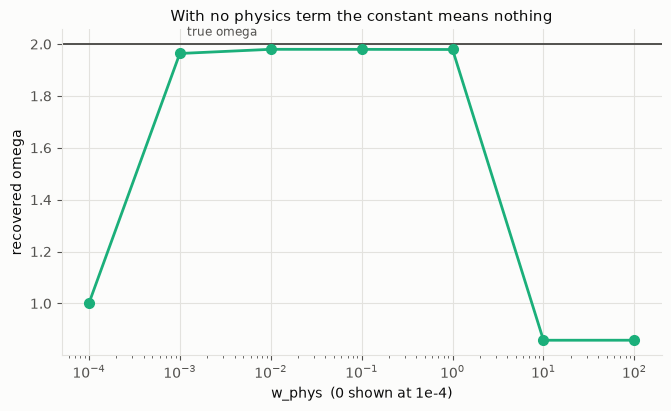

In [6]:
w, om, err, dl = zip(*rows)
fig, ax = plt.subplots(figsize=(6.6, 4.0))
ax.axhline(OMEGA_TRUE, color=P.INK_2, lw=1.4)
ax.annotate("true omega", xy=(1.2e-3, OMEGA_TRUE), xytext=(0, 6),
            textcoords="offset points", color=P.INK_2, fontsize=8.5)
ax.plot([max(x, 1e-4) for x in w], om, "-o", color=P.ARM_COLOR["pinn"])
ax.set_xscale("log"); ax.set_xlabel("w_phys  (0 shown at 1e-4)")
ax.set_ylabel("recovered omega")
ax.set_title("With no physics term the constant means nothing")
plt.show()

## The finding

At `w_phys = 0` the network fits the eight points perfectly well and
`omega` drifts to whatever is left over: **the data loss barely changes
while the recovered constant is badly wrong**. The physics term is not a
regulariser you tune for accuracy. It is what makes the parameter
*identifiable* at all.

This repository measures the same effect on real data: at `w_phys = 0` the
recovered `GM_sun` is 19.5% wrong and the CMB temperature 1.33% wrong, while
held-out error hardly moves. A PINN that fits well is not thereby measuring
anything.

Next: [T3](T3_gravity.ipynb) puts this on a real ephemeris.